In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

GRAFICOS = 'graficos'
BASE = 'base-de-dados'

In [2]:
receitas_raw = pd.read_csv(
    f'{BASE}/2025_Receitas.csv',
    sep=';',
    encoding='iso-8859-1',
    dtype=str,
    quotechar='"'
)
receitas_raw.columns = receitas_raw.columns.str.strip().str.strip('"')
print(receitas_raw.shape)
print(receitas_raw.columns.tolist())

(175278, 16)
['CÓDIGO ÓRGÃO SUPERIOR', 'NOME ÓRGÃO SUPERIOR', 'CÓDIGO ÓRGÃO', 'NOME ÓRGÃO', 'CÓDIGO UNIDADE GESTORA', 'NOME UNIDADE GESTORA', 'CATEGORIA ECONÔMICA', 'ORIGEM RECEITA', 'ESPÉCIE RECEITA', 'DETALHAMENTO', 'VALOR PREVISTO ATUALIZADO', 'VALOR LANÇADO', 'VALOR REALIZADO', 'PERCENTUAL REALIZADO', 'DATA LANÇAMENTO', 'ANO EXERCÍCIO']


In [3]:
receitas_raw.head(3)

,CÓDIGO ÓRGÃO SUPERIOR,NOME ÓRGÃO SUPERIOR,CÓDIGO ÓRGÃO,NOME ÓRGÃO,CÓDIGO UNIDADE GESTORA,NOME UNIDADE GESTORA,CATEGORIA ECONÔMICA,ORIGEM RECEITA,ESPÉCIE RECEITA,DETALHAMENTO,VALOR PREVISTO ATUALIZADO,VALOR LANÇADO,VALOR REALIZADO,PERCENTUAL REALIZADO,DATA LANÇAMENTO,ANO EXERCÍCIO
0,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110060,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"Bens, Direitos e Valores Incorporados ao Patr","BENS,DIR.VAL.RENUNCIA VOLUNT.NAO PENAL-PRINC.","0,00","0,00","157,96","0,00",27/06/2025,2025
1,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110060,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"Bens, Direitos e Valores Incorporados ao Patr","BENS,DIR.VAL.RENUN.VOLUNT.NAO PENAL-MUL.JUR.","0,00","0,00","13,67","0,00",19/02/2025,2025
2,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110060,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"Bens, Direitos e Valores Incorporados ao Patr","BENS,DIR.VAL.RENUNCIA VOLUNT.NAO PENAL-PRINC.","0,00","0,00","18789,54","0,00",17/10/2025,2025


In [4]:
MONEY_COLS_REC = [
    'VALOR PREVISTO ATUALIZADO',
    'VALOR LANÇADO',
    'VALOR REALIZADO',
    'PERCENTUAL REALIZADO',
]

receitas = receitas_raw.copy()

for col in MONEY_COLS_REC:
    receitas[col] = (
        receitas[col]
        .str.strip('"')
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

print(receitas[MONEY_COLS_REC].dtypes)
print(receitas[MONEY_COLS_REC].isnull().sum())

VALOR PREVISTO ATUALIZADO    float64
VALOR LANÇADO                float64
VALOR REALIZADO              float64
PERCENTUAL REALIZADO         float64
dtype: object
VALOR PREVISTO ATUALIZADO    0
VALOR LANÇADO                0
VALOR REALIZADO              0
PERCENTUAL REALIZADO         0
dtype: int64


In [5]:
STR_COLS_REC = [
    'NOME ÓRGÃO SUPERIOR', 'NOME ÓRGÃO',
    'CATEGORIA ECONÔMICA', 'ORIGEM RECEITA', 'ESPÉCIE RECEITA',
    'DATA LANÇAMENTO', 'ANO EXERCÍCIO',
]

for col in STR_COLS_REC:
    receitas[col] = receitas[col].str.strip('"').str.strip()

print(receitas['CATEGORIA ECONÔMICA'].unique())
print(receitas['ANO EXERCÍCIO'].unique())

<StringArray>
[                       'Receitas Correntes',
                       'Receitas de Capital',
  'Receitas Correntes - intra-orçamentárias',
                            'Sem informação',
 'Receitas de Capital - intra-orçamentárias']
Length: 5, dtype: str
<StringArray>
['2025']
Length: 1, dtype: str


In [6]:
before = len(receitas)
receitas = receitas.dropna(subset=['VALOR REALIZADO'])
print(f'Dropped {before - len(receitas)} rows with null VALOR REALIZADO')
print(f'Remaining: {len(receitas)} rows')

Dropped 0 rows with null VALOR REALIZADO
Remaining: 175278 rows


In [7]:
desp_path = f'{BASE}/2025_OrcamentoDespesa.csv'
desp_raw = pd.read_csv(desp_path, sep=';', encoding='iso-8859-1', dtype=str, quotechar='"')
desp_raw.columns = [c.strip().strip('"') for c in desp_raw.columns]
print(desp_raw.shape)
desp_raw.head(3)

(26160, 26)


,EXERCÍCIO,CÓDIGO ÓRGÃO SUPERIOR,NOME ÓRGÃO SUPERIOR,CÓDIGO ÓRGÃO SUBORDINADO,NOME ÓRGÃO SUBORDINADO,CÓDIGO UNIDADE ORÇAMENTÁRIA,NOME UNIDADE ORÇAMENTÁRIA,CÓDIGO FUNÇÃO,NOME FUNÇÃO,CÓDIGO SUBFUNÇÃO,...,NOME CATEGORIA ECONÔMICA,CÓDIGO GRUPO DE DESPESA,NOME GRUPO DE DESPESA,CÓDIGO ELEMENTO DE DESPESA,NOME ELEMENTO DE DESPESA,ORÇAMENTO INICIAL (R$),ORÇAMENTO ATUALIZADO (R$),ORÇAMENTO EMPENHADO (R$),ORÇAMENTO REALIZADO (R$),% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)
0,2025,13000,Justiça Militar,13000,Justiça Militar - Unidades com vínculo direto,13101,JUSTICA MILITAR,02,Judiciária,061,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,"0,00","0,00","185311,65","24282,78","0,00%"
1,2025,20000,Presidência da República,20101,Presidência da República,20101,PRESIDENCIA DA REPUBLICA,04,Administração,122,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,"207500,00","207500,00","207500,00","207500,00","100,00%"
2,2025,20000,Presidência da República,20101,Presidência da República,20101,PRESIDENCIA DA REPUBLICA,04,Administração,131,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,"857837716,65","857837716,65","857837716,65","441054554,37","51,41%"


In [8]:
desp_raw.head(3)

,EXERCÍCIO,CÓDIGO ÓRGÃO SUPERIOR,NOME ÓRGÃO SUPERIOR,CÓDIGO ÓRGÃO SUBORDINADO,NOME ÓRGÃO SUBORDINADO,CÓDIGO UNIDADE ORÇAMENTÁRIA,NOME UNIDADE ORÇAMENTÁRIA,CÓDIGO FUNÇÃO,NOME FUNÇÃO,CÓDIGO SUBFUNÇÃO,...,NOME CATEGORIA ECONÔMICA,CÓDIGO GRUPO DE DESPESA,NOME GRUPO DE DESPESA,CÓDIGO ELEMENTO DE DESPESA,NOME ELEMENTO DE DESPESA,ORÇAMENTO INICIAL (R$),ORÇAMENTO ATUALIZADO (R$),ORÇAMENTO EMPENHADO (R$),ORÇAMENTO REALIZADO (R$),% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)
0,2025,13000,Justiça Militar,13000,Justiça Militar - Unidades com vínculo direto,13101,JUSTICA MILITAR,02,Judiciária,061,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,"0,00","0,00","185311,65","24282,78","0,00%"
1,2025,20000,Presidência da República,20101,Presidência da República,20101,PRESIDENCIA DA REPUBLICA,04,Administração,122,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,"207500,00","207500,00","207500,00","207500,00","100,00%"
2,2025,20000,Presidência da República,20101,Presidência da República,20101,PRESIDENCIA DA REPUBLICA,04,Administração,131,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,"857837716,65","857837716,65","857837716,65","441054554,37","51,41%"


In [9]:
MONEY_COLS_DESP = [
    'ORÇAMENTO INICIAL (R$)',
    'ORÇAMENTO ATUALIZADO (R$)',
    'ORÇAMENTO EMPENHADO (R$)',
    'ORÇAMENTO REALIZADO (R$)'
]
PCT_COL_DESP = '% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)'

desp = desp_raw.copy()

for col in MONEY_COLS_DESP:
    desp[col] = (
        desp[col]
        .str.strip().str.strip('"')
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    desp[col] = pd.to_numeric(desp[col], errors='coerce')

# Strip % suffix and convert
desp[PCT_COL_DESP] = (
    desp[PCT_COL_DESP]
    .str.strip().str.strip('"')
    .str.replace('%', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)
desp[PCT_COL_DESP] = pd.to_numeric(desp[PCT_COL_DESP], errors='coerce')

print(desp[MONEY_COLS_DESP + [PCT_COL_DESP]].dtypes)

ORÇAMENTO INICIAL (R$)                                            float64
ORÇAMENTO ATUALIZADO (R$)                                         float64
ORÇAMENTO EMPENHADO (R$)                                          float64
ORÇAMENTO REALIZADO (R$)                                          float64
% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)    float64
dtype: object


In [10]:
STR_COLS_DESP = [
    'NOME ÓRGÃO SUPERIOR',
    'NOME ÓRGÃO SUBORDINADO',
    'NOME FUNÇÃO',
    'NOME SUBFUNÇÃO',
    'NOME PROGRAMA ORÇAMENTÁRIO',
    'NOME AÇÃO',
    'NOME CATEGORIA ECONÔMICA',
    'NOME GRUPO DE DESPESA',
    'NOME ELEMENTO DE DESPESA'
]

for col in STR_COLS_DESP:
    if col in desp.columns:
        desp[col] = desp[col].str.strip().str.strip('"')

print("String cols cleaned")

String cols cleaned


In [11]:
before = len(desp)
desp = desp.dropna(subset=['ORÇAMENTO REALIZADO (R$)'])
print(f"Dropped {before - len(desp)} rows. Remaining: {len(desp)}")
print(desp[MONEY_COLS_DESP].dtypes)
desp.head(3)

Dropped 0 rows. Remaining: 26160
ORÇAMENTO INICIAL (R$)       float64
ORÇAMENTO ATUALIZADO (R$)    float64
ORÇAMENTO EMPENHADO (R$)     float64
ORÇAMENTO REALIZADO (R$)     float64
dtype: object


,EXERCÍCIO,CÓDIGO ÓRGÃO SUPERIOR,NOME ÓRGÃO SUPERIOR,CÓDIGO ÓRGÃO SUBORDINADO,NOME ÓRGÃO SUBORDINADO,CÓDIGO UNIDADE ORÇAMENTÁRIA,NOME UNIDADE ORÇAMENTÁRIA,CÓDIGO FUNÇÃO,NOME FUNÇÃO,CÓDIGO SUBFUNÇÃO,...,NOME CATEGORIA ECONÔMICA,CÓDIGO GRUPO DE DESPESA,NOME GRUPO DE DESPESA,CÓDIGO ELEMENTO DE DESPESA,NOME ELEMENTO DE DESPESA,ORÇAMENTO INICIAL (R$),ORÇAMENTO ATUALIZADO (R$),ORÇAMENTO EMPENHADO (R$),ORÇAMENTO REALIZADO (R$),% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)
0,2025,13000,Justiça Militar,13000,Justiça Militar - Unidades com vínculo direto,13101,JUSTICA MILITAR,02,Judiciária,061,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,0.000000e+00,0.000000e+00,1.853116e+05,2.428278e+04,0.00
1,2025,20000,Presidência da República,20101,Presidência da República,20101,PRESIDENCIA DA REPUBLICA,04,Administração,122,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,2.075000e+05,2.075000e+05,2.075000e+05,2.075000e+05,100.00
2,2025,20000,Presidência da República,20101,Presidência da República,20101,PRESIDENCIA DA REPUBLICA,04,Administração,131,...,DESPESAS CORRENTES,3,Outras Despesas Correntes,39,Outros Serviços de Terceiros - Pessoa Jurídica,8.578377e+08,8.578377e+08,8.578377e+08,4.410546e+08,51.41


In [12]:
# ── ANÁLISE ESTATÍSTICA — RECEITAS ──────────────────────────────────────────

In [13]:
MONEY_COLS_REC = ['VALOR PREVISTO ATUALIZADO', 'VALOR LANÇADO', 'VALOR REALIZADO', 'PERCENTUAL REALIZADO']
desc_rec = receitas[MONEY_COLS_REC].describe(percentiles=[.25, .75, .90])
print("=== Estatísticas Descritivas — Receitas ===")
display(desc_rec.round(2))

=== Estatísticas Descritivas — Receitas ===


,VALOR PREVISTO ATUALIZADO,VALOR LANÇADO,VALOR REALIZADO,PERCENTUAL REALIZADO
count,1.752780e+05,1.752780e+05,1.752780e+05,175278.00
mean,3.263536e+07,1.264539e+05,3.202960e+07,0.00
std,4.530363e+09,4.963988e+07,8.270617e+08,0.25
min,0.000000e+00,-6.568062e+09,-9.249915e+09,-0.61
25%,0.000000e+00,0.000000e+00,3.149800e+02,0.00
75%,0.000000e+00,0.000000e+00,5.544113e+04,0.00
90%,0.000000e+00,0.000000e+00,7.946372e+05,0.00
max,1.622299e+12,6.964636e+09,1.240236e+11,85.01


In [14]:
cat_rec = (
    receitas.groupby('CATEGORIA ECONÔMICA')[['VALOR PREVISTO ATUALIZADO', 'VALOR REALIZADO']]
    .agg(['mean', 'sum', 'median'])
    .round(2)
)
print("=== Receita por Categoria Econômica ===")
display(cat_rec)

=== Receita por Categoria Econômica ===


VALOR PREVISTO ATUALIZADO  \
                                                               mean   
CATEGORIA ECONÔMICA                                                   
Receitas Correntes                                     1.786018e+07   
Receitas Correntes - intra-orçamentárias               9.547433e+06   
Receitas de Capital                                    5.776192e+08   
Receitas de Capital - intra-orçamentárias              0.000000e+00   
Sem informação                                         0.000000e+00   

                                                                \
                                                    sum median   
CATEGORIA ECONÔMICA                                              
Receitas Correntes                         3.001474e+12    0.0   
Receitas Correntes - intra-orçamentárias   2.419320e+10    0.0   
Receitas de Capital                        2.694594e+12    0.0   
Receitas de Capital - intra-orçamentárias  0.000000e+00    0.0   
Sem informação                             0.000000e+00    0.0   

                                          VALOR REALIZADO                \
                                                     mean           sum   
CATEGORIA ECONÔMICA                                                       
Receitas Correntes                           1.712608e+07  2.878107e+12   
Receitas Correntes - intra-orçamentárias     9.494098e+06  2.405804e+10   
Receitas de Capital                          5.812831e+08  2.711686e+12   
Receitas de Capital - intra-orçamentárias    1.561070e+07  2.341605e+08   
Sem informação                               0.000000e+00  0.000000e+00   

                                                        
                                                median  
CATEGORIA ECONÔMICA                                     
Receitas Correntes                             3568.78  
Receitas Correntes - intra-orçamentárias       2160.68  
Receitas de Capital                          181129.61  
Receitas de Capital - intra-orçamentárias  13814062.08  
Sem informação                                    0.00

In [15]:
corr_rec = receitas[['VALOR PREVISTO ATUALIZADO', 'VALOR REALIZADO']].corr()
print("=== Correlação: Previsto vs Realizado (Receitas) ===")
display(corr_rec.round(4))

=== Correlação: Previsto vs Realizado (Receitas) ===


,VALOR PREVISTO ATUALIZADO,VALOR REALIZADO
VALOR PREVISTO ATUALIZADO,1.0000,0.0162
VALOR REALIZADO,0.0162,1.0000


In [16]:
perc_orgao_rec = (
    receitas.groupby('NOME ÓRGÃO SUPERIOR')['PERCENTUAL REALIZADO']
    .quantile([0.25, 0.75, 0.90])
    .unstack()
    .rename(columns={0.25: 'P25', 0.75: 'P75', 0.90: 'P90'})
    .round(2)
    .sort_values('P75', ascending=False)
)
print("=== Percentis P25/P75/P90 de % Realizado por Órgão Superior (Receitas) ===")
display(perc_orgao_rec.head(20))

=== Percentis P25/P75/P90 de % Realizado por Órgão Superior (Receitas) ===


,P25,P75,P90
NOME ÓRGÃO SUPERIOR,,,
Advocacia-Geral da União,0.0,0.0,0.0
Banco Central do Brasil - Orçamento Fiscal e,0.0,0.0,0.0
Ministério da Agricultura e Pecuária,0.0,0.0,0.0
"Ministério da Ciência, Tecnologia e Inovaç",0.0,0.0,0.0
Ministério da Cultura,0.0,0.0,0.0
Ministério da Defesa,0.0,0.0,0.0
Ministério da Educação,0.0,0.0,0.0
Ministério da Fazenda,0.0,0.0,0.0
Ministério da Gestão e da Inovação em Ser,0.0,0.0,0.0


In [17]:
mediana_exec_rec = receitas.groupby('NOME ÓRGÃO SUPERIOR')['PERCENTUAL REALIZADO'].median().sort_values(ascending=False)
print(f"=== Mediana Global da Taxa de Execução (Receitas): {receitas['PERCENTUAL REALIZADO'].median():.2f}% ===")
print("\nMediana por Órgão Superior (top 20):")
display(mediana_exec_rec.head(20).round(2))

=== Mediana Global da Taxa de Execução (Receitas): 0.00% ===

Mediana por Órgão Superior (top 20):


NOME ÓRGÃO SUPERIOR
Advocacia-Geral da União                        0.0
Banco Central do Brasil - Orçamento Fiscal e    0.0
Ministério da Agricultura e Pecuária            0.0
Ministério da Ciência, Tecnologia e Inovaç      0.0
Ministério da Cultura                           0.0
Ministério da Defesa                            0.0
Ministério da Educação                          0.0
Ministério da Fazenda                           0.0
Ministério da Gestão e da Inovação em Ser       0.0
Ministério da Integração e do Desenvolvime      0.0
Ministério da Justiça e Segurança Pública       0.0
Ministério da Pesca e Aquicultura               0.0
Ministério da Previdência Social                0.0
Ministério da Saúde                             0.0
Ministério das Cidades                          0.0
Ministério das Comunicações                     0.0
Ministério das Mulheres, Igualdade Racial, d    0.0
Ministério das Relações Exteriores              0.0
Ministério de Minas e Energia               

In [18]:
std_exec_rec = receitas.groupby('NOME ÓRGÃO SUPERIOR')['PERCENTUAL REALIZADO'].std().sort_values(ascending=False)
print("=== Desvio Padrão da Taxa de Execução por Órgão (Receitas) ===")
display(std_exec_rec.head(20).round(2))

=== Desvio Padrão da Taxa de Execução por Órgão (Receitas) ===


NOME ÓRGÃO SUPERIOR
Ministério da Justiça e Segurança Pública       0.58
Ministério da Educação                          0.36
Ministério da Cultura                           0.26
Ministério da Defesa                            0.20
Ministério da Ciência, Tecnologia e Inovaç      0.17
Presidência da República                        0.13
Ministério do Desenvolvimento, Indústria, C     0.07
Ministério do Meio Ambiente e Mudança do Cl     0.05
Ministério do Desenvolvimento Agrário e Agr     0.04
Ministério das Relações Exteriores              0.04
Ministério da Fazenda                           0.04
Banco Central do Brasil - Orçamento Fiscal e    0.04
Ministério da Gestão e da Inovação em Ser       0.03
Ministério das Comunicações                     0.02
Ministério da Agricultura e Pecuária            0.02
Ministério da Saúde                             0.02
Ministério das Cidades                          0.02
Ministério do Planejamento e Orçamento          0.02
Ministério da Pesca e Aqui

In [19]:
# ── ANÁLISE ESTATÍSTICA — DESPESAS ──────────────────────────────────────────

In [20]:
MONEY_COLS_DESP = ['ORÇAMENTO INICIAL (R$)', 'ORÇAMENTO ATUALIZADO (R$)', 'ORÇAMENTO EMPENHADO (R$)', 'ORÇAMENTO REALIZADO (R$)']
PCT_COL_DESP = '% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)'
desc_desp = desp[MONEY_COLS_DESP + [PCT_COL_DESP]].describe(percentiles=[.25, .75, .90])
print("=== Estatísticas Descritivas — Despesas ===")
display(desc_desp.round(2))

=== Estatísticas Descritivas — Despesas ===


,ORÇAMENTO INICIAL (R$),ORÇAMENTO ATUALIZADO (R$),ORÇAMENTO EMPENHADO (R$),ORÇAMENTO REALIZADO (R$),% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)
count,2.616000e+04,2.616000e+04,2.616000e+04,2.616000e+04,26160.00
mean,2.149526e+08,2.193432e+08,1.983082e+08,1.854645e+08,63.24
std,1.106339e+10,1.105817e+10,9.774321e+09,9.656145e+09,1062.31
min,-3.000000e+10,-3.273000e+06,0.000000e+00,0.000000e+00,0.00
25%,1.730136e+04,1.192253e+04,7.120400e+02,0.000000e+00,0.00
75%,2.800000e+06,2.207592e+06,1.794929e+06,1.093338e+06,95.28
90%,2.160593e+07,1.783450e+07,1.561984e+07,1.066240e+07,100.00
max,1.559519e+12,1.559519e+12,1.356201e+12,1.356201e+12,170723.00


In [21]:
func_desp = (
    desp.groupby('NOME FUNÇÃO')[['ORÇAMENTO ATUALIZADO (R$)', 'ORÇAMENTO REALIZADO (R$)']]
    .agg(['mean', 'sum', 'median'])
    .round(2)
    .sort_values(('ORÇAMENTO REALIZADO (R$)', 'sum'), ascending=False)
)
print("=== Despesa por Função ===")
display(func_desp.head(20))

=== Despesa por Função ===


ORÇAMENTO ATUALIZADO (R$)                           \
                                          mean           sum     median   
NOME FUNÇÃO                                                               
Encargos especiais                2.122712e+09  3.440916e+12   30360.00   
Previdência social                8.879833e+08  1.085116e+12  896251.75   
Assistência social                8.768956e+08  2.911293e+11  405559.65   
Saúde                             1.891492e+08  2.411653e+11  513389.00   
Educação                          1.913936e+07  1.905514e+11  187338.52   
Trabalho                          4.707177e+08  1.237988e+11  239238.41   
Defesa nacional                   5.138297e+07  9.978573e+10  267831.30   
Agricultura                       6.896999e+07  4.848590e+10  183517.95   
Administração                     1.895720e+07  3.510874e+10  256000.37   
Gestão ambiental                  3.459903e+07  3.255768e+10  112500.00   
Ciência e Tecnologia              4.019247e+07  3.544976e+10  133425.08   
Segurança pública                 4.039807e+07  1.850232e+10  864356.18   
Transporte                        1.918891e+07  1.776893e+10  381819.56   
Relações exteriores               2.119705e+07  5.044897e+09  206622.16   
Organização agrária               1.254399e+07  5.180667e+09  216115.47   
Comunicações                      1.684134e+07  3.738777e+09  248078.50   
Cultura                           4.924008e+06  2.900241e+09  140000.00   
Indústria                         5.943644e+06  2.561710e+09  223000.00   
Urbanismo                         3.033879e+07  9.496041e+09  576000.00   
Comércio e serviços               4.535795e+07  5.941891e+09  299000.00   

                     ORÇAMENTO REALIZADO (R$)                           
                                         mean           sum     median  
NOME FUNÇÃO                                                             
Encargos especiais               1.734525e+09  2.811664e+12       0.00  
Previdência social               8.311911e+08  1.015716e+12  502218.98  
Assistência social               8.549631e+08  2.838477e+11   75041.68  
Saúde                            1.693762e+08  2.159546e+11  110661.97  
Educação                         1.614994e+07  1.607889e+11   63629.56  
Trabalho                         4.402111e+08  1.157755e+11   26196.15  
Defesa nacional                  4.531814e+07  8.800784e+10   97093.16  
Agricultura                      5.754792e+07  4.045619e+10   20426.70  
Administração                    1.583430e+07  2.932513e+10   94114.34  
Gestão ambiental                 2.136267e+07  2.010227e+10   18000.00  
Ciência e Tecnologia             2.118761e+07  1.868748e+10   43787.06  
Segurança pública                3.146644e+07  1.441163e+10   70574.15  
Transporte                       1.392736e+07  1.289673e+10   18943.52  
Relações exteriores              1.975524e+07  4.701748e+09   71843.03  
Organização agrária              1.020273e+07  4.213727e+09   29903.44  
Comunicações                     1.106109e+07  2.455563e+09  116755.46  
Cultura                          3.957578e+06  2.331013e+09   25693.45  
Indústria                        5.178794e+06  2.232060e+09   89608.50  
Urbanismo                        6.048207e+06  1.893089e+09   18229.03  
Comércio e serviços              1.216165e+07  1.593176e+09    7616.73

In [22]:
corr_desp = desp[['ORÇAMENTO ATUALIZADO (R$)', 'ORÇAMENTO REALIZADO (R$)']].corr()
print("=== Correlação: Orçamento Atualizado vs Realizado (Despesas) ===")
display(corr_desp.round(4))

=== Correlação: Orçamento Atualizado vs Realizado (Despesas) ===


,ORÇAMENTO ATUALIZADO (R$),ORÇAMENTO REALIZADO (R$)
ORÇAMENTO ATUALIZADO (R$),1.0000,0.9986
ORÇAMENTO REALIZADO (R$),0.9986,1.0000


In [23]:
PCT_COL_DESP = '% REALIZADO DO ORÇAMENTO (COM RELAÇÃO AO ORÇAMENTO ATUALIZADO)'
perc_orgao_desp = (
    desp.groupby('NOME ÓRGÃO SUPERIOR')[PCT_COL_DESP]
    .quantile([0.25, 0.75, 0.90])
    .unstack()
    .rename(columns={0.25: 'P25', 0.75: 'P75', 0.90: 'P90'})
    .round(2)
    .sort_values('P75', ascending=False)
)
print("=== Percentis P25/P75/P90 de % Realizado por Órgão Superior (Despesas) ===")
display(perc_orgao_desp.head(20))

=== Percentis P25/P75/P90 de % Realizado por Órgão Superior (Despesas) ===


,P25,P75,P90
NOME ÓRGÃO SUPERIOR,,,
Ministério do Planejamento e Orçamento,0.00,100.00,100.0
Ministério das Comunicações,0.00,100.00,100.0
"Ministério da Ciência, Tecnologia e Inovação",0.00,99.82,100.0
Presidência da República,0.00,99.60,100.0
Ministério das Relações Exteriores,26.44,98.91,100.0
Ministério da Defesa,6.62,98.85,100.0
Ministério do Meio Ambiente e Mudança do Clima,0.00,98.04,100.0
Ministério de Minas e Energia,29.59,97.99,100.0
"Ministério do Desenvolvimento, Indústria, Comércio e Serviços",0.00,97.90,100.0


In [24]:
mediana_exec_desp = desp.groupby('NOME ÓRGÃO SUPERIOR')[PCT_COL_DESP].median().sort_values(ascending=False)
std_exec_desp = desp.groupby('NOME ÓRGÃO SUPERIOR')[PCT_COL_DESP].std().sort_values(ascending=False)
print(f"=== Mediana Global da Taxa de Execução (Despesas): {desp[PCT_COL_DESP].median():.2f}% ===")
print("\nMediana por Órgão Superior (top 20):")
display(mediana_exec_desp.head(20).round(2))
print("\nDesvio Padrão por Órgão Superior (top 20):")
display(std_exec_desp.head(20).round(2))

=== Mediana Global da Taxa de Execução (Despesas): 76.97% ===

Mediana por Órgão Superior (top 20):


NOME ÓRGÃO SUPERIOR
Ministério das Relações Exteriores                                91.67
Ministério do Desenvolvimento, Indústria, Comércio e Serviços     86.17
Ministério da Educação                                            85.68
Banco Central do Brasil - Orçamento Fiscal e Seguridade Social    85.58
Ministério de Minas e Energia                                     85.23
Ministério do Planejamento e Orçamento                            82.06
Presidência da República                                          81.35
Controladoria-Geral da União                                      80.29
Ministério da Previdência Social                                  79.79
Ministério da Gestão e da Inovação em Serviços Públicos           77.90
Advocacia-Geral da União                                          77.69
Ministério do Meio Ambiente e Mudança do Clima                    77.42
Ministério da Saúde                                               75.82
Ministério das Comunicações                 


Desvio Padrão por Órgão Superior (top 20):


NOME ÓRGÃO SUPERIOR
Ministério da Defesa                                                            3765.92
Ministério das Cidades                                                          1048.04
Ministério do Planejamento e Orçamento                                            44.50
Ministério do Desenvolvimento e Assistência Social, Família e Combate à Fome      43.96
Ministério da Saúde                                                               43.92
Ministério da Justiça e Segurança Pública                                         43.79
Ministério do Meio Ambiente e Mudança do Clima                                    43.79
Ministério de Portos e Aeroportos                                                 43.65
Ministério da Ciência, Tecnologia e Inovação                                      43.59
Ministério da Cultura                                                             43.49
Ministério das Comunicações                                                       43.20
Ministério d

In [25]:
# ── VISUALIZAÇÕES ────────────────────────────────────────────────────────────

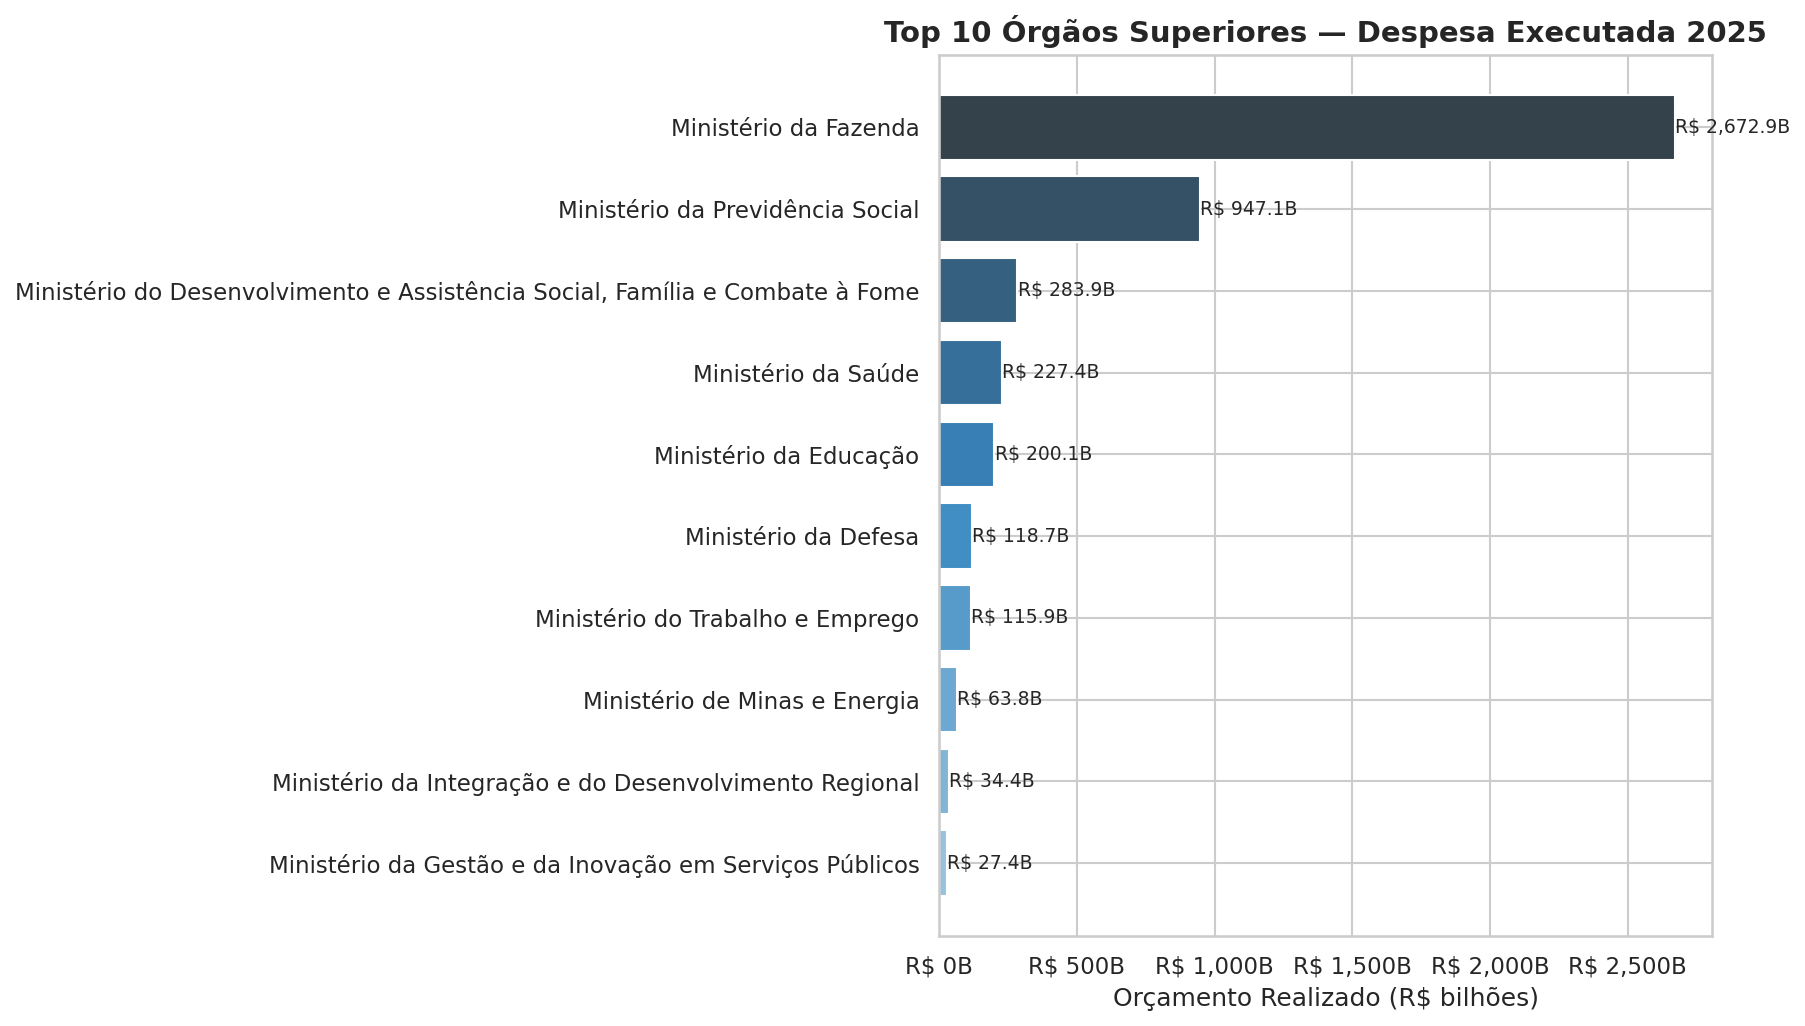

Saved: graficos/top10_orgaos_despesa.png


In [26]:
top10 = (
    desp.groupby('NOME ÓRGÃO SUPERIOR')['ORÇAMENTO REALIZADO (R$)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10.columns = ['Órgão Superior', 'Realizado (R$)']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top10['Órgão Superior'][::-1],
    top10['Realizado (R$)'][::-1] / 1e9,
    color=sns.color_palette('Blues_d', 10)
)
ax.set_xlabel('Orçamento Realizado (R$ bilhões)', fontsize=12)
ax.set_title('Top 10 Órgãos Superiores — Despesa Executada 2025', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}B'))

for bar, val in zip(bars, top10['Realizado (R$)'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'R$ {val/1e9:,.1f}B', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{GRAFICOS}/top10_orgaos_despesa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graficos/top10_orgaos_despesa.png")

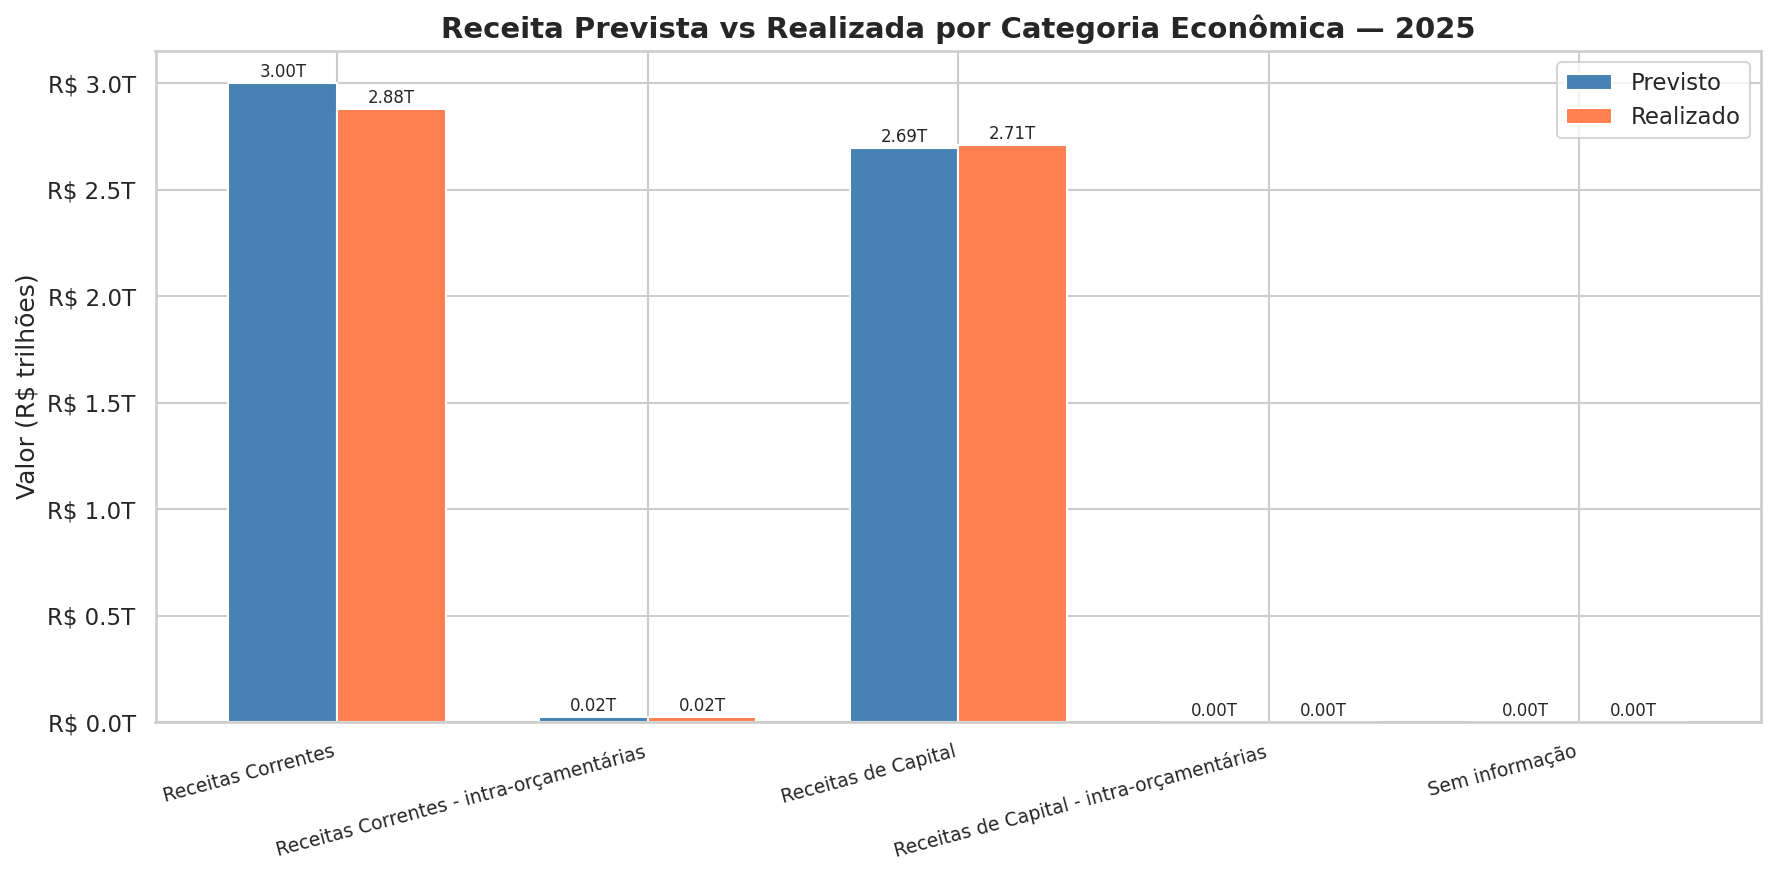

Saved: graficos/receita_prevista_realizada.png


In [27]:
cat_summary = (
    receitas.groupby('CATEGORIA ECONÔMICA')[['VALOR PREVISTO ATUALIZADO', 'VALOR REALIZADO']]
    .sum()
    .reset_index()
)
cat_summary.columns = ['Categoria', 'Previsto', 'Realizado']

x = range(len(cat_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], cat_summary['Previsto'] / 1e12, width, label='Previsto', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], cat_summary['Realizado'] / 1e12, width, label='Realizado', color='coral')

ax.set_xticks(list(x))
ax.set_xticklabels(cat_summary['Categoria'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Valor (R$ trilhões)', fontsize=12)
ax.set_title('Receita Prevista vs Realizada por Categoria Econômica — 2025', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.1f}T'))

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}T', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}T', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{GRAFICOS}/receita_prevista_realizada.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graficos/receita_prevista_realizada.png")

In [ ]:
func_scatter = (
    desp.groupby('NOME FUNÇÃO')[['ORÇAMENTO INICIAL (R$)', 'ORÇAMENTO REALIZADO (R$)']]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    func_scatter['ORÇAMENTO INICIAL (R$)'] / 1e9,
    func_scatter['ORÇAMENTO REALIZADO (R$)'] / 1e9,
    s=80, alpha=0.7, color='steelblue', edgecolors='navy', linewidth=0.5
)

max_val = max(func_scatter['ORÇAMENTO INICIAL (R$)'].max(), func_scatter['ORÇAMENTO REALIZADO (R$)'].max()) / 1e9
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Realizado = Inicial')

top5 = func_scatter.nlargest(5, 'ORÇAMENTO REALIZADO (R$)')
for _, row in top5.iterrows():
    ax.annotate(row['NOME FUNÇÃO'],
                xy=(row['ORÇAMENTO INICIAL (R$)']/1e9, row['ORÇAMENTO REALIZADO (R$)']/1e9),
                xytext=(5, 5), textcoords='offset points', fontsize=7, alpha=0.9)

ax.set_xlabel('Orçamento Inicial (R$ bilhões)', fontsize=12)
ax.set_ylabel('Orçamento Realizado (R$ bilhões)', fontsize=12)
ax.set_title('Orçamento Inicial vs Realizado por Função — 2025', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}B'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}B'))
ax.legend()

plt.tight_layout()
plt.savefig(f'{GRAFICOS}/scatter_orcamento_executado.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graficos/scatter_orcamento_executado.png")

In [ ]:
exec_orgao = (
    desp.groupby('NOME ÓRGÃO SUPERIOR')[PCT_COL_DESP]
    .median()
    .dropna()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
exec_orgao.columns = ['Órgão Superior', 'Mediana % Realizado']

fig, ax = plt.subplots(figsize=(12, 9))
colors = ['#2ecc71' if v >= 75 else '#f39c12' if v >= 50 else '#e74c3c'
          for v in exec_orgao['Mediana % Realizado']]
ax.barh(exec_orgao['Órgão Superior'][::-1], exec_orgao['Mediana % Realizado'][::-1], color=colors[::-1])

ax.axvline(x=75, color='green', linestyle='--', alpha=0.5, label='75%')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50%')

ax.set_xlabel('Mediana da Taxa de Execução Orçamentária (%)', fontsize=12)
ax.set_title('Taxa de Execução Orçamentária por Órgão Superior — Top 20 (2025)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend()

for i, (_, row) in enumerate(exec_orgao[::-1].iterrows()):
    ax.text(row['Mediana % Realizado'] + 0.5, i, f"{row['Mediana % Realizado']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{GRAFICOS}/execucao_por_orgao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graficos/execucao_por_orgao.png")